In [ ]:
!pip install fiftyone


import fiftyone as fo
import fiftyone.zoo as foz
import matplotlib.pyplot as plt
from collections import Counter


# Load dataset (64115 samples)
dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="train",
    label_types=["detections"],
    classes=["person"],
    max_samples=64115
)



INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/coco-2017/train' if necessary


Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


INFO:fiftyone.utils.coco:Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


32586 images found; downloading the remaining 31529


INFO:fiftyone.utils.coco:32586 images found; downloading the remaining 31529


...

INFO:fiftyone.zoo.datasets:Loading 'coco-2017' split 'train'


 100% |█████████████| 64115/64115 [10.6m elapsed, 0s remaining, 118.7 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 64115/64115 [10.6m elapsed, 0s remaining, 118.7 samples/s]      


Dataset 'coco-2017-train-64115' created


INFO:fiftyone.zoo.datasets:Dataset 'coco-2017-train-64115' created


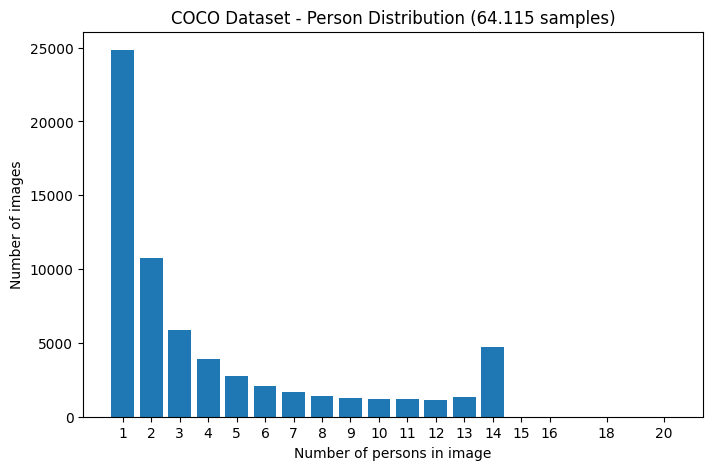

Saved as coco_person_distribution.csv


In [ ]:

person_counts = []

for sample in dataset:

    detections = sample.ground_truth.detections
    count = 0

    for det in detections:
        if det.label == "person":
            count += 1

    person_counts.append(count)


distribution = Counter(person_counts)


x = list(distribution.keys())
y = list(distribution.values())

plt.figure(figsize=(8,5))
plt.bar(x, y)
plt.xticks(x)
plt.xlabel("Number of persons in image")
plt.ylabel("Number of images")
plt.title("COCO Dataset - Person Distribution (64.115 samples)")
plt.show()

# Save results
import csv

with open("coco_person_distribution.csv", "w", newline="") as f:
    writer = csv.writer(f)

    # header
    writer.writerow(["persons_in_image", "images"])

    # data
    for persons, images in sorted(distribution.items()):
        writer.writerow([persons, images])

print("Saved as coco_person_distribution.csv")



In [ ]:
from google.colab import files
files.download("coco_person_distribution.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>